#**Future Navigators Study Group Discussion**


## **Welcome**

Welcome to the maiden edition of our study group discussion. Remember this is a discussion session among fellow learners feel free to ask your questions, clear your doubts and express yourself

**Areas to work on**
<ol>
<li> Intro to machine learning </li>
<li> Steps in using ML models </li>
<li> Linear Regression </li>
  <ul>
  <li>Line of best fit </li>
  <li> Least square method </li>
  <li> Simple linear regression </li>
  <li> Multiple linear regression </li>
  </ul>
<li> Decision Trees </li>
<li> Model Performance evaluation </li>
  <ul>
  <li> Splitting data </li>
  <li> Performance metrics </li>
</ul>
<li> Ensemble methods </li>
  <ul>
  <li> Basics </li>
  <li> Heterogeneous Ensemble Methods </li>
  <li> Homogeneous Ensemble Methods </li>
  </ul>
</ol>

**Later**
<ol>
<li> Feature Selection (Variable selection) </li>
<li> Regularization </li>
<li> saving and restoring models in python </li>
</ol>

Now, straight to the discussion

## **What is Machine Learning**


Machine Learning is the use and development of computer systems that are able to learn and adapt without following explicit instructions, by using algorithms and statistical models to analyse and draw inferences from patterns in data

-- Oxford Dictionary

In 1959, Arthur Samuel who is a pioneer in the field of machine learning defined it as "field of study that gives computers the ability to learn without being explicitly programmed"

Machine learning is a subfield of artificial intelligence focused on making computers learn from and act on data

### **Predictors and Response Variables**

Lets say we have an equation

``` y = mx + c ```


We say that x is the independent variable and y is the dependent variable

In other words, we say that x is the predictor and y is the response varaible

For instance, we can predict the price of a house using the area of the house.


Lets say we have the data below:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def generate_data():
  area = np.array(range(10,31))
  np.random.shuffle(area)
  noise = 30 * (np.random.random(len(area)) - 0.5)
  price = 3 * area + noise
  df = pd.DataFrame({'Area': area, 'Price': price})
  return df, area, price

In [ ]:
df, area, price = generate_data()
df

,Area,Price
0,22,72.874028
1,17,36.041226
2,27,94.328572
3,19,69.530943
4,12,34.018253
5,10,16.874877
6,15,37.774584
7,18,54.625755
8,11,34.681648
9,13,24.968213


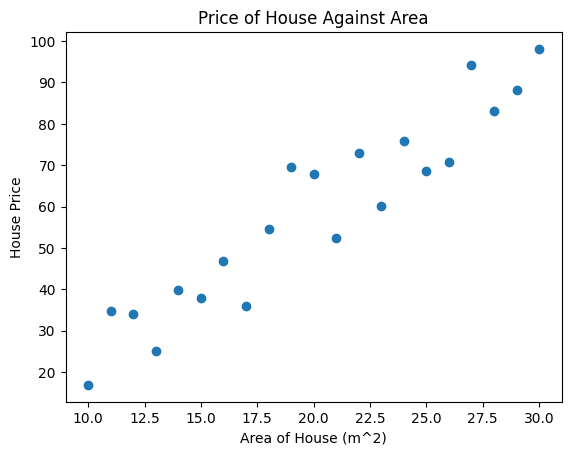

In [ ]:
plt.scatter(area, price)
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.title("Price of House Against Area")
plt.show()

## **Using Machine Learning (ML) Models**

There are three (3) steps to use machine learning models (after importing the models of course)

### **1. Initialize your Model and Set Hyperparameters**

Select and create an instance of the ML model you wish to use

In our case, we would be using the LinearRegression model from Scikit-Learn

In [ ]:
import sklearn
from sklearn.linear_model import LinearRegression

In [ ]:
ml_model = LinearRegression()

Hyperparameters are the parameters we set before traiining an ML model and do not change during training

Lets get a look at the parameters we can set for this model

In [ ]:
LinearRegression?

In [ ]:
ml_model?

We do not need to set any hyperparameter in our case

### **2. Train the Model**

This is the stage where we we make the model learn from our data

Our goal is to get an equation of a straight line of the form

``` y = mx + c ```

 With this equation, we can predict the value of the response variable (house price) given the area of the house

 The model is going to get the best value for m and c that minimises errors

In [ ]:
ml_model.fit(area.reshape(-1, 1), price.reshape(-1, 1))

LinearRegression()

Now that we have our model, the final step is to predict values

### **3. Make Prediction**

We use our model to get a prediction of house price given the area of the house

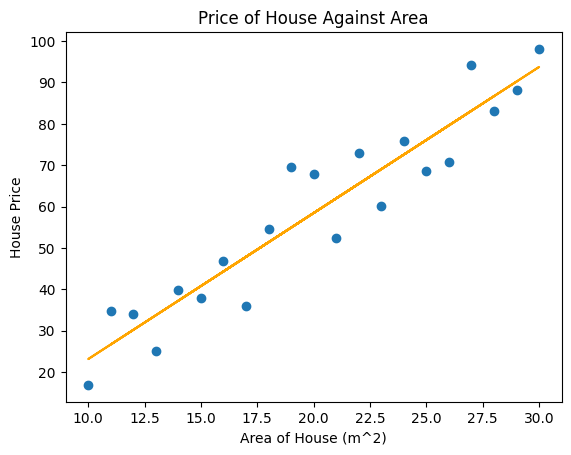

In [ ]:
predicted_price1 = ml_model.predict(area.reshape(-1,1))

plt.scatter(area, price)
plt.plot(area.flatten(), predicted_price1.flatten(), c='orange')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.title("Price of House Against Area")
plt.show()

Lets understand how the model makes predictions

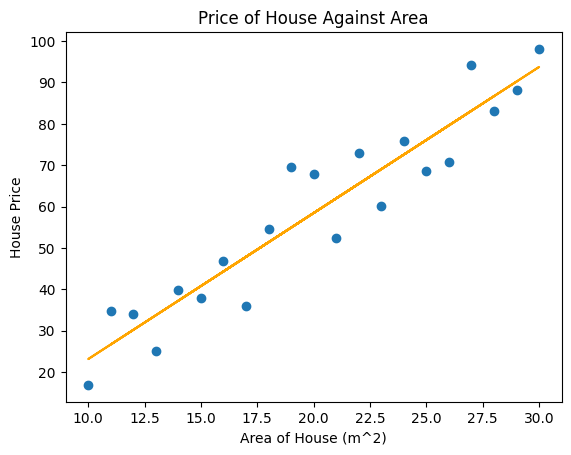

In [ ]:
m = ml_model.coef_
c = ml_model.intercept_

predicted_price2 = m * area + c

plt.scatter(area, price)
plt.plot(area.flatten(), predicted_price2.flatten(), c='orange')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.title("Price of House Against Area")
plt.show()

What would be the predicted house price for a house with an arbitrary area?

In [ ]:
def show_prediction(given_area):
  predicted_price1 = ml_model.predict(area.reshape(-1,1))

  model_input = np.array(given_area).reshape(-1, 1)
  pred_price = ml_model.predict(model_input)

  print(f"The predicted price is {pred_price[0][0]:.2f}")

  plt.scatter(area, price)
  plt.plot(area.flatten(), predicted_price1.flatten(), c='orange')
  plt.vlines(x = given_area, ymin=min(predicted_price1)-3, ymax=pred_price,
            colors='red', linestyles='--')
  plt.hlines(y = pred_price, xmin=min(area)-1, xmax=given_area,
            colors='red', linestyles='--')
  plt.plot(given_area, pred_price, 'go', markersize=10)
  plt.axis([min(area)-1, max(area)+1, min(predicted_price1)-3, max(predicted_price1)+3])
  plt.xlabel("Area of House (m^2)")
  plt.ylabel("House Price")
  plt.title("Price of House Against Area")
  plt.show()

The predicted price is 58.43


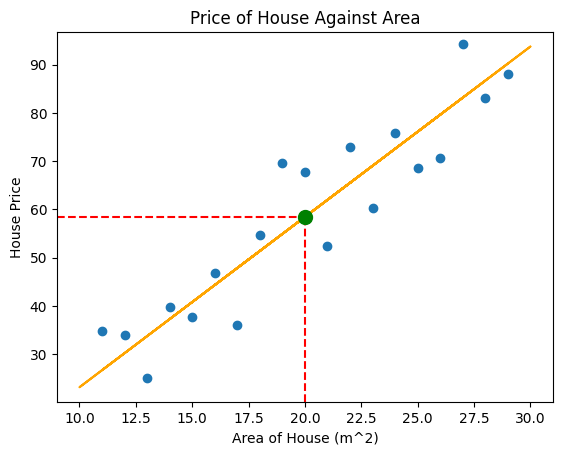

In [ ]:
show_prediction(20)

## **Linear Regression**

There are a lot of models we can use for ML problems

The model used above is the linear regression model

## **Line of best fit**

consider the lines below and tell the best one (the one with best fit to our data)

In [ ]:
from ipywidgets import interact, interact_manual, widgets

In [ ]:
@interact
def show_errors(m=m[0][0], c=c[0]):
  pred_price = m*area + c

  area2 = area.flatten()
  price2 = price.flatten()
  pred_price2 = pred_price.flatten()

  sum_of_errors = np.sum(np.abs(price2-pred_price2))
  print(f"Sum of absolute errors is {sum_of_errors:.5f}")

  ymins = [price2[i] if price2[i] < pred_price2[i] else pred_price2[i]
          for i in range(len(price2))]
  ymaxs = [pred_price2[i] if price2[i] < pred_price2[i] else price2[i]
          for i in range(len(price2))]

  plt.vlines(x=area2, ymin=ymins, ymax=ymaxs, colors='red')

  plt.scatter(area2, price2)
  plt.plot(area2, pred_price2, c='orange')

  plt.xlabel("Area of House (m^2)")
  plt.ylabel("House Price")
  plt.title("Price of House Against Area")
  plt.show()

interactive(children=(FloatSlider(value=3.5311892491204384, description='m', max=10.593567747361316, min=-3.53…

### **Least Square Method**

In least square method, we calculate the values for the slope (m) and intercept c directly using mathematical equations

Least squared error is based on the property that the optimum slope and intercept values are the values when the squared error is lowest

Mathematically, we say when the direction of the squared error changes or when the derivative is equal to zero with respect to each of the parameters

##### **Function Definitions**

In [ ]:
def show_error_vs_slope():
  price2 = price.flatten()
  num_m_values = 50
  m_values = np.linspace(m-5, m+5, num_m_values).reshape(num_m_values,-1)
  pred_price = m_values*area + c
  pred_price2 = pred_price

  Q = np.zeros(m_values.shape[0])
  for i in range(m_values.shape[0]):
    Q[i] = np.sum(np.square(price2-pred_price2[i]))

  ind_min_Q = np.argmin(Q)
  min_Q = Q[ind_min_Q]
  min_m = m_values[ind_min_Q]

  print(f"Minimum m = {min_m[0]:.5f}")
  print(f"Minimum Q = {min_Q:.5f}")

  plt.plot(m_values.flatten(), Q)
  plt.plot(min_m, min_Q, 'go', markersize=10)
  plt.xlabel('Slope')
  plt.ylabel('Squared error')
  plt.title("Plot of Squared Error Against slope")
  plt.show()

In [ ]:
def show_error_vs_intercept():
  price2 = price.flatten()
  num_c_values = 50
  c_values = np.linspace(c-5, c+5, num_c_values).reshape(num_c_values,-1)
  pred_price = m*area + c_values
  pred_price2 = pred_price

  Q = np.zeros(c_values.shape[0])
  for i in range(c_values.shape[0]):
    Q[i] = np.sum(np.square(price2-pred_price2[i]))

  ind_min_Q = np.argmin(Q)
  min_Q = Q[ind_min_Q]
  min_c = c_values[ind_min_Q]

  print(f"Minimum c = {min_c[0]:.5f}")
  print(f"Minimum Q = {min_Q:.5f}")

  plt.plot(c_values.flatten(), Q)
  plt.plot(min_c, min_Q, 'go', markersize=10)
  plt.xlabel('Intercept')
  plt.ylabel('Squared error')
  plt.title("Plot of Squared Error Against Intercept")
  plt.show()

### **Visualising**

In [ ]:
show_error_vs_slope()

In [ ]:
show_error_vs_intercept()

The formula for sum of squares of residuals (Q) is

$$Q = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

We know that $\hat{y}_i$ is gotten as

$$\hat{y}_i = m x_i+c$$

So,

$$Q = \sum_{i=1}^{n}(y_i - ( m x_i+c))^2$$

The formular to get the slope (m) and interceptb(c) directly are gotten differentiating the formula for Q partially with respect to m then partially with respect to c and equaing both to zero

The equations for \(m\) and \(c\) are:   
   
$$m = \frac{\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n(x_i-\bar{x})^2}$$   
   
and:   
   
$$c = \bar{y} - m \bar{x}$$

where $\bar{y}$ and $\bar{x}$ are the mean values of \(y\) and \(x\) in our dataset, respectively.

To get how the derivation is done, watch the derivation and explanation on youtube here

https://youtu.be/ewnc1cXJmGA?feature=shared

Lets implement this and see how it performs

In [ ]:
# Calculate mean of X and Y
x_bar = np.mean(area)
y_bar = np.mean(price)

# Calculate the slope (m) of the regression line using the least squares method
m = sum((area - x_bar) * (price - y_bar)) / sum((area - x_bar) ** 2)

# Calculate the intercept (c) of the regression line
c = y_bar - m * x_bar

# Output the calculated slope and intercept
print(f"Slope = {m:.5f}")
print(f"Intercept = {c:.5f}")

predicted_price3 = m * area + c

plt.scatter(area, price)
plt.plot(area.flatten(), predicted_price3.flatten(), c='orange')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.title("Price of House Against Area")
plt.show()

### **Multiple Linear Regression**

Multiple linear regression works same way as linear rgression but this time, we have more than one preditor variables

In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [ ]:
X_raw = housing.data
y_raw = housing.target

In [ ]:
X = pd.DataFrame(X_raw)
y = pd.DataFrame(y_raw)

In [ ]:
X.head()

In [ ]:
X.shape

In [ ]:
y.head()

In [ ]:
y.head()

#### **Creating a Multiple Linear Regression Model**

Do you still remeber the steps

In [ ]:
mult_lin_reg = LinearRegression()
mult_lin_reg.fit(X, y)
y_pred = mult_lin_reg.predict(X)

min_val = np.min(y_raw) if np.min(y_raw) < np.min(y_pred) else np.min(y_pred)
max_val = np.max(y_raw) if np.max(y_raw) < np.max(y_pred) else np.max(y_pred)
plt.scatter(y, y_pred)
plt.plot([min_val, max_val], [min_val, max_val], c='orange')
plt.xlabel("True House Price")
plt.ylabel("Predicted House Price")
plt.title("Predicted Price of House Against True Price of House")
plt.show()

## **Decision Tree**

Decision tree is a type of algorithm that works like having multiple if else statement

Lets build our model to see how it works

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dec_tree = DecisionTreeRegressor(max_depth=2)

dec_tree.fit(area.reshape(-1,1), price.reshape(-1,1))

In [ ]:
predicted_price4 = dec_tree.predict(area.reshape(-1,1))

sort_arg = np.argsort(area.flatten())

plt.scatter(area, price)
plt.plot(area.flatten()[sort_arg], predicted_price4.flatten()[sort_arg], c='orange')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.title("Price of House Against Area")
plt.show()

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(9,9))
# assigned a random variable name to the plot to suppress text output
_ = plot_tree(dec_tree, feature_names=['Area'],  filled=True)

Lets play around with the hyperparameter and see the effect

Lets check the predictions from this model

In [ ]:
model_input = 17.5
refined_model_input = np.array([model_input]).reshape(-1, 1)

model_pred = dec_tree.predict(refined_model_input)
print(f"The prediction for {model_input} is {model_pred[0]:.3f}")

## **Model Performance Evaluation**

The reason we train model is that they should be able to perfom well on unseen data

Therefore, after building an ML model, before we can say that we are done, we have to test how the model performs on unseen data

### **Splitting Data**

This brought about splitting our data into training set and test set. We train the model on the training set, then we check (test) the model performance on the test set.

Another splitting strategy is to split our data into training, validation and test set. In this type of splitting, we train the model on the training set, then we test the performance on the test set to get idea on how to refine the model. We iterate this process until a satifiable performance is gotten. Then in the end, we test the performance on the test set and use that as the performance measure of the model. This is to ensure that the data has not been overfitted to the training or validation set.

One handy function we use for splitting our data is the ```train_test_split()``` function in sklearn which randomly splits data into 2 different sets given the proportion (percentage)

Lets check out the function to know how it works

In [ ]:
from sklearn.model_selection import train_test_split

train_test_split?

Using the first method, we want to split as follows:
- Training set - 80%
- Test set - 20%

In [ ]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(area, price, test_size=0.2)

In [ ]:
plt.scatter(X_train1, y_train1, c='#038cfc', label='Training')
plt.scatter(X_test1, y_test1, c='orange', label='Test')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.legend()
plt.title("Price of House Against Area")
plt.show()

Using the second method, we want to split as follows:
- Training set - 70%
- Validation set - 15%
- Test set - 15%

There is one constraint we should take note of though. The function ```Train_test_split()``` does not split into more than 2 sets at the same time

So, we would have to do our splitting gradually. A common way we can go about this is
- split the data into training and lets say dev set which contains both validation and test sets.
- split the dev set into validation and test sets

In [ ]:
X_train2, X_dev, y_train2, y_dev = train_test_split(area, price, test_size=0.3)
X_val2, X_test2, y_val2, y_test2 = train_test_split(X_dev, y_dev, test_size=0.3)

In [ ]:
plt.scatter(X_train2, y_train2, c='#038cfc', label='Train')
plt.scatter(X_val2, y_val2, c='green', label='Validation')
plt.scatter(X_test2, y_test2, c='orange', label='Test')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.legend()
plt.title("Price of House Against Area")
plt.show()

We have seen how to split data randomly in a specified proportion

How do we split using conditions?

One way to go about this is using list comprehensions

Lets say we want to use data whose index are multiples of 4 for test set while the rest would be used for training. we can do it this way

In [ ]:
X_train3 = [area[i] for i in range(area.shape[0]) if i%4 != 0]
y_train3 = [price[i] for i in range(price.shape[0]) if i%4 != 0]

X_test3 = [area[i] for i in range(area.shape[0]) if i%4 == 0]
y_test3 = [price[i] for i in range(price.shape[0]) if i%4 == 0]

In [ ]:
plt.scatter(X_train3, y_train3, c='#038cfc', label='Training')
plt.scatter(X_test3, y_test3, c='orange', label='Test')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.legend()
plt.title("Price of House Against Area")
plt.show()

### **Performance Evaluation**

After splitting the data the next thing is to build the model using the training set then check the performance using either the validation or test set as appropriate

This is done by getting predictions for the validation or test set then comparing with the real value

for this evaluation stage, only the firat splitting strategy would be used to save time

First, lets build the model

Hope you know the drill?
What are the steps?

In [ ]:
lin_reg_model = LinearRegression()

lin_reg_model.fit(X_train1.reshape(-1,1), y_train1.reshape(-1,1))

lin_reg_pred = lin_reg_model.predict(X_test1.reshape(-1,1))

There are a number of metrics we can use.

We would be focusing on the following:
- Residual
- Mean Absolute Error (MAE)
- Mean squared Error (MSE)
- Root mean Squared Error (RMSE)
- Root Mean Squared Logarithmic Error (RMSLE)

#### **Residuals**

Residuals are the erros in our prediction. It is the distance between predicted values and the actual values

In [ ]:
residuals = lin_reg_pred.flatten() - y_test1
plt.scatter(range(len(residuals)), residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Data")
plt.ylabel("Residual")
plt.title("Plot of Residuals from Model Prediction")
plt.show()

#### **Mean Absolute Error (MAE)**

The mean absolute error is the average of the absolute values of the errors

The formula for MAE is given as:

$$ MAE = \frac{\sum_{i=1}^{n} |\hat{y}_i - y|}{n}$$

In [ ]:
from sklearn.metrics import mean_absolute_error as MAE

In [ ]:
mae_value = MAE(y_test1, lin_reg_pred)

print(f"The MAE is {mae_value:.5f}")

#### **Mean Squared Error (MSE)**

The mean squared error is the sum of the squares of the errors

The formula for MSE is given as:

$$ MSE = \frac{\sum_{i=1}^{n} (\hat{y}_i - y)^2}{n}$$

In [ ]:
from sklearn.metrics import mean_squared_error as MSE

In [ ]:
mse_value = MSE(y_test1, lin_reg_pred)

print(f"The MSE is {mse_value:.5f}")

#### **Root Mean Squared Error (RMSE)**

The root mean squared error (RMSE) is the sqaure root of of the sum of squares of the residuals. It is the suare root of MSE

The formula for RMSE is given as:

$$ RMSE = \sqrt{\frac{\sum_{i=1}^{n} (\hat{y}_i - y)^2}{n}} $$

In [ ]:
from sklearn.metrics import mean_squared_error as MSE

In [ ]:
rmse_value = MSE(y_test1, lin_reg_pred, squared=False)

print(f"The RMSE is {rmse_value:.5f}")

#### **Root Mean Squared Logarithmic Error (RMSLE)**

The Root Mean Squared Logarithmic Error is also another metric to check the performance of our model

The formula for RMSLE is given as:

$$ RMSLE = \sqrt{\frac{\sum_{i=1}^{n} (log(\hat{y}_i + 1) - log(y_i +1))^2}{n}} $$

In [ ]:
from sklearn.metrics import mean_squared_log_error as MSLE

In [ ]:
rmsle_value = MSLE(y_test1, lin_reg_pred, squared=False)

print(f"The RMSLE is {rmsle_value:.5f}")

## **Ensemble Methods**

Ensemble learning is a machine learning paradigm where multiple models (often called "weak learners") are trained to solve the same problem and combined to get better results

-- Directly from the modules

### **Categories of Ensemble Methods**

There are two broad main categories of ensemble methods

These are:
- Heterogeneous Methods
- Homogeneous Methods

### **Heterogeneous Ensemble Methods**

These category of methods involves training different models on the same data then combining the resuls to get our final result

For this methods we would be using our first splitting method (train and test sets) and RMSE as the performance metric

Lets split our data

In [ ]:
X_train_he_ens, X_test_he_ens, y_train_he_ens, y_test_he_ens = train_test_split(area, price, test_size=0.2)

Lets train our models

#### **Linear Regression Model**

In [ ]:
lin_reg_ens = LinearRegression()

lin_reg_ens.fit(X_train_he_ens.reshape(-1,1), y_train_he_ens.reshape(-1,1))

y_pred_lin_ens = lin_reg_ens.predict(X_test_he_ens.reshape(-1,1))

In [ ]:
RMSE = MSE(y_test_he_ens, y_pred_lin_ens, squared=False)
print(f"RMSE: {RMSE:.5f}")

X_domain = np.linspace(min(X_train_he_ens), max(X_train_he_ens), 100)
y_pred = lin_reg_ens.predict(X_domain.reshape(-1,1))

plt.scatter(X_train_he_ens, y_train_he_ens)
plt.plot(X_domain, y_pred, c='orange', label='Prediction')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.legend()
plt.title("Price of House Against Area")
plt.show()

#### **Decision Tree Model**

In [ ]:
dec_tree_ens = DecisionTreeRegressor(max_depth=3)

dec_tree_ens.fit(X_train_he_ens.reshape(-1,1), y_train_he_ens.reshape(-1,1))

y_pred_tree_ens = dec_tree_ens.predict(X_test_he_ens.reshape(-1,1))

In [ ]:
RMSE = MSE(y_test_he_ens, y_pred_tree_ens, squared=False)
print(f"RMSE: {RMSE:.5f}")

X_domain = np.linspace(min(X_train_he_ens), max(X_train_he_ens), 100)
y_pred = dec_tree_ens.predict(X_domain.reshape(-1,1))

plt.scatter(X_train_he_ens, y_train_he_ens)
plt.plot(X_domain, y_pred, c='orange', label='Prediction')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.legend()
plt.title("Price of House Against Area")
plt.show()

Now, lets combine our predictions

The following are the variuos heterogeneous methods we can use

#### **1. Voting**

In voting we take the average or weighted average of the predictions

In [ ]:
from sklearn.ensemble import VotingRegressor

In [ ]:
models = [("LR",lin_reg_ens),("DT",dec_tree_ens)]
model_weightings = np.array([0.8,0.2])
v_reg = VotingRegressor(estimators=models,weights=model_weightings)

In [ ]:
v_reg.fit(X_train_he_ens.reshape(-1,1), y_train_he_ens)

In [ ]:
y_pred_v_reg = v_reg.predict(X_test_he_ens.reshape(-1,1))
RMSE = MSE(y_test_he_ens, y_pred_v_reg, squared=False)
print(f"RMSE: {RMSE:.5f}")

X_domain = np.linspace(min(X_train_he_ens), max(X_train_he_ens), 100)
y_pred = v_reg.predict(X_domain.reshape(-1,1))

plt.scatter(X_train_he_ens, y_train_he_ens)
plt.plot(X_domain, y_pred, c='orange', label='Prediction')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.legend()
plt.title("Price of House Against Area")
plt.show()

In [ ]:
input = 17.5
output = v_reg.predict(np.array([input]).reshape(1, -1))
print(output[0])

In [ ]:
input = 17.5
output_lin_reg = lin_reg_ens.predict(np.array([input]).reshape(-1, 1))
output_dec_tree = dec_tree_ens.predict(np.array([input]).reshape(-1, 1))
output = 0.8 *output_lin_reg + 0.2 * output_dec_tree
print(output[0][0])

#### **2. Stacking**

In stacking, we train another model to choose the best weights for us

In [ ]:
from sklearn.ensemble import StackingRegressor

In [ ]:
models = [("LR",lin_reg_ens),("DT",dec_tree_ens)]
meta_learner_reg = LinearRegression()
s_reg = StackingRegressor(estimators=models, final_estimator=meta_learner_reg)

In [ ]:
s_reg.fit(X_train_he_ens.reshape(-1,1), y_train_he_ens)

In [ ]:
y_pred_s_reg = s_reg.predict(X_test_he_ens.reshape(-1,1))
RMSE = MSE(y_test_he_ens, y_pred_s_reg, squared=False)
print(f"RMSE: {RMSE:.5f}")

X_domain = np.linspace(min(X_train_he_ens), max(X_train_he_ens), 100)
y_pred = s_reg.predict(X_domain.reshape(-1,1))

plt.scatter(X_train_he_ens, y_train_he_ens)
plt.plot(X_domain, y_pred, c='orange', label='Prediction')
plt.xlabel("Area of House (m^2)")
plt.ylabel("House Price")
plt.legend()
plt.title("Price of House Against Area")
plt.show()

In [ ]:
input = 17.5
output = s_reg.predict(np.array([input]).reshape(1, -1))
print(output[0])

In [ ]:
m = s_reg.final_estimator_.coef_

In [ ]:
c = s_reg.final_estimator_.intercept_

In [ ]:
input = 17.5
output_lin_reg = lin_reg_ens.predict(np.array([input]).reshape(-1, 1))
output_dec_tree = dec_tree_ens.predict(np.array([input]).reshape(-1, 1))
output = m[0] *output_lin_reg + m[1] * output_dec_tree + c
print(output[0][0])